In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score, precision_score, recall_score, mean_absolute_error, confusion_matrix, ConfusionMatrixDisplay, root_mean_squared_error, mean_squared_error
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegressionCV
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import shutup
shutup.please()

In [3]:
df_c19 = pd.read_csv("../../data/outputs/cord19/c19_final.csv")
df_m17 = pd.read_csv("../../data/outputs/m17+/m17_final.csv")

### Train-test splitting

In [4]:
df_c19 = df_c19.sample(n=len(df_c19),random_state=42) 
df_m17 = df_m17.sample(n=len(df_m17), random_state=42)

In [5]:
def get_train_test(df):
    df.drop(['science_field', 'collaborators', 'journal_name', 'title','abstract'], axis = 1, inplace= True, errors='ignore')
    df_c19[['rigor', 'novelty', 'accessibility']] = df_c19[['rigor', 'novelty', 'accessibility']].astype('category')
    enc = OrdinalEncoder(categories=[['low', 'medium', 'high']])
    df['rigor'] = enc.fit_transform(df[['rigor']])
    df['novelty'] = enc.fit_transform(df[['novelty']])
    df['accessibility'] = enc.fit_transform(df[['accessibility']])
    if 'evaluation' in df.columns:
        y  = df['evaluation']
        X =  df.drop(['evaluation', 'eval_reduced'], axis=1, errors='ignore')
    else:
        y  = df['cited']
        X =  df.drop(['cited'], axis=1)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    return  X_train, X_test, y_train, y_test

In [6]:
X_train_m17, X_test_m17, y_train_m17, y_test_m17 = get_train_test(df_m17)
X_train_c19, X_test_c19, y_train_c19, y_test_c19 = get_train_test(df_c19)

In [6]:
X_train_c19

,rigor,novelty,grammar,replicability,accessibility,mathematics,computer_sciences,physical_sciences,chemical_sciences,earth_and_related_sciences,...,exploratory_research,focus_groups,interviews,mixed_methods,observation,qualitative_research,quantitative_research,questionnaires,secondary_research,survey_methodology
545,2.0,2.0,0,1,2.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
624,2.0,2.0,0,1,2.0,0.0,1.0,1.0,1.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2739,1.0,0.0,0,0,1.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2786,2.0,2.0,0,1,2.0,0.0,1.0,0.0,0.0,0.0,...,1,0,0,1,0,1,0,0,0,0
394,1.0,2.0,0,1,2.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2619,1.0,2.0,0,1,2.0,1.0,1.0,1.0,1.0,1.0,...,0,0,0,1,0,1,0,0,0,1
2078,1.0,2.0,0,1,2.0,0.0,1.0,1.0,1.0,0.0,...,0,0,0,0,0,0,0,0,0,0
890,2.0,2.0,0,1,2.0,0.0,0.0,0.0,0.0,0.0,...,1,0,0,1,0,1,1,0,0,0
2517,2.0,2.0,0,1,2.0,0.0,1.0,0.0,0.0,1.0,...,1,0,0,1,0,1,0,0,0,0


In [7]:
def get_conf_matrix(y_test, y_pred):
    fig, _ = plt.subplots(nrows=1, figsize=(5,5))
    ax = plt.subplot(1, 1, 1)
    ax.grid(False)

    intensity = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix = intensity, display_labels=set(y_test))
    _ = disp.plot(ax=ax)


'Dummy Accuracy score: 0.18'

'Dummy Recall score: 0.17966617069173846'

'Dummy F1 score: 0.1797522920654036'

'Dummy Precision score: 0.18013220443145786'

'Dummy MAE score: 1.62'

'Dummy RMSE score: 2.004993765576342'

'Dummy MSE score: 4.02'

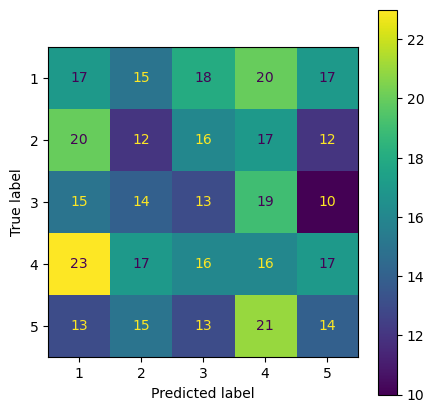

In [8]:
dummy = DummyClassifier(strategy='uniform', random_state=42)
dummy.fit(X_train_m17, y_train_m17)
y_pred = dummy.predict(X_test_m17)
display(f"Dummy Accuracy score: {accuracy_score(y_test_m17, y_pred)}")
display(f"Dummy Recall score: {recall_score(y_test_m17, y_pred, average='macro')}")
display(f"Dummy F1 score: {f1_score(y_test_m17, y_pred, average='macro')}")
display(f"Dummy Precision score: {precision_score(y_test_m17, y_pred, average='macro')}")
display(f"Dummy MAE score: {mean_absolute_error(y_test_m17, y_pred)}")
display(f"Dummy RMSE score: {root_mean_squared_error(y_test_m17, y_pred)}")
display(f"Dummy MSE score: {mean_squared_error(y_test_m17, y_pred)}")
get_conf_matrix(y_test_m17, y_pred)


'Dummy Accuracy score: 0.5016666666666667'

'Dummy Recall score: 0.502809020075576'

'Dummy F1 score: 0.5016320577817904'

'Dummy Precision score: 0.5028044871794872'

'Dummy MAE score: 0.49833333333333335'

'Dummy RMSE score: 0.7059272861515791'

'Dummy MSE score: 0.49833333333333335'

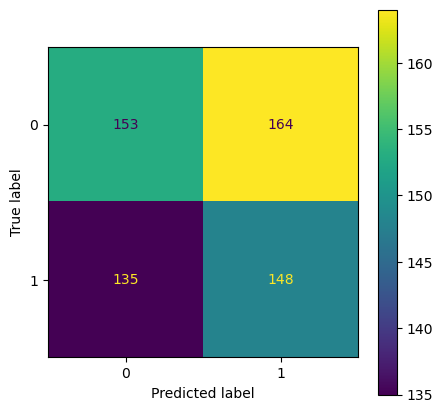

In [9]:
dummy = DummyClassifier(strategy='uniform', random_state=42)
dummy.fit(X_train_c19, y_train_c19)
y_pred = dummy.predict(X_test_c19)
display(f"Dummy Accuracy score: {accuracy_score(y_test_c19, y_pred)}")
display(f"Dummy Recall score: {recall_score(y_test_c19, y_pred, average='macro')}")
display(f"Dummy F1 score: {f1_score(y_test_c19, y_pred, average='macro')}")
display(f"Dummy Precision score: {precision_score(y_test_c19, y_pred, average='macro')}")
display(f"Dummy MAE score: {mean_absolute_error(y_test_c19, y_pred)}")
display(f"Dummy RMSE score: {root_mean_squared_error(y_test_c19, y_pred)}")
display(f"Dummy MSE score: {mean_squared_error(y_test_c19, y_pred)}")
get_conf_matrix(y_test_c19, y_pred)


In [8]:
grid_rfc = {
 'max_depth': [10, 20, 30, 40, 45, 50],
 'max_features': ['log2', 'sqrt', 30],
 'min_samples_leaf': [30, 40, 50, 60, 70, 90],
 'min_samples_split': [20, 30, 50, 60, 90],
 'n_estimators': [ 100, 200, 400, 1000]}

grid_abc = {
    'n_estimators': [ 100, 200, 400, 1000],
    'learning_rate': [0.1, 0.2, 0.4, 1, 1.5]}

In [9]:

def train_rfc(X_train, y_train, X_test, y_test , metric = None):
    rf = RandomForestClassifier()
    rf_grid = RandomizedSearchCV(estimator = rf, param_distributions= grid_rfc, n_iter= 2000, cv = 5, verbose=3, n_jobs = -1, random_state=42)
    rf_grid.fit(X_train, y_train)
    best = rf_grid.best_estimator_
    y_pred = best.predict(X_test)
    display(f"Best params: {rf_grid.best_params_}")
    display(f"Random Forest Classifier Accuracy score: {accuracy_score(y_test, y_pred)}")
    display(f"Random Forest Classifier Recall score: {recall_score(y_test, y_pred, average='macro')}")
    display(f"Random Forest Classifier F1 score: {f1_score(y_test, y_pred, average='macro')}")
    display(f"Random Forest Classifier Precision score: {precision_score(y_test, y_pred, average='macro')}")
    display(f"Random Forest Classifier MAE score: {mean_absolute_error(y_test, y_pred)}")
    display(f"Random Forest Classifier RMSE score: {root_mean_squared_error(y_test, y_pred)}")
    display(f"Random Forest Classifier MSE score: {mean_squared_error(y_test, y_pred)}")
    get_conf_matrix(y_test, y_pred)

    result = permutation_importance(
        best, X_test, y_test, n_repeats=30, random_state=42, n_jobs=2
    )
    forest_importances = pd.Series(result.importances_mean, index=X_train.columns)
    forest_importances = forest_importances.sort_values(ascending=False)[:16]
    display(forest_importances)
    fig, ax = plt.subplots()
    forest_importances.plot.bar(ax=ax)
    ax.set_title("Feature importances using permutation on full model")
    ax.set_ylabel("Mean accuracy decrease")
    fig.tight_layout()
    plt.show()

def train_gbc(X_train, y_train, X_test, y_test, metric = None):
    gbc = GradientBoostingClassifier()
    gbc_grid = RandomizedSearchCV(estimator = gbc, n_iter=2000 , param_distributions = grid_rfc, cv = 5, verbose=3, n_jobs = -1, scoring=metric, random_state=42)
    gbc_grid.fit(X_train, y_train)
    best = gbc_grid.best_estimator_

    y_pred = gbc_grid.predict(X_test)
    display(f"Best params: {gbc_grid.best_params_}")
    display(f"Gradient Boosting Classifier Accuracy score: {accuracy_score(y_test, y_pred)}")
    display(f"Gradient Boosting Classifier Recall score: {recall_score(y_test, y_pred, average='macro')}")
    display(f"Gradient Boosting Classifier F1 score: {f1_score(y_test,  y_pred, average='macro')}")
    display(f"Gradient Boosting Classifier Precision score: {precision_score(y_test, y_pred, average='macro')}")
    display(f"Gradient Boosting Classifier MAE score: {mean_absolute_error(y_test, y_pred)}")
    display(f"Gradient Boosting Classifier RMSE score: {root_mean_squared_error(y_test, y_pred)}")
    display(f"Gradient Boosting Classifier MSE score: {mean_squared_error(y_test, y_pred)}")
    get_conf_matrix(y_test, y_pred)


    result = permutation_importance(
        best, X_test, y_test, n_repeats=30, random_state=42, n_jobs=2
    )
    forest_importances = pd.Series(result.importances_mean, index=X_train.columns)
    forest_importances = forest_importances.sort_values(ascending=False)[:16]
    display(forest_importances)

    fig, ax = plt.subplots()
    forest_importances.plot.bar(ax=ax)
    ax.set_title("Feature importances using permutation on full model")
    ax.set_ylabel("Mean accuracy decrease")
    fig.tight_layout()
    plt.show()


def train_abc(X_train, y_train, X_test, y_test, metric = None ):
    abc = AdaBoostClassifier()
    abc_grid = RandomizedSearchCV(estimator = abc, n_iter=2000 , param_distributions = grid_abc, cv = 5, verbose=3, n_jobs = -1, scoring=metric,random_state=42 )
    abc_grid.fit(X_train, y_train)
    best = abc_grid.best_estimator_

    y_pred = abc_grid.predict(X_test)
    display(f"Best params: {abc_grid.best_params_}")
    display(f"Ada Boosting Classifier Accuracy score: {accuracy_score(y_test, y_pred)}")
    display(f"Ada Boosting Classifier Recall score: {recall_score(y_test, y_pred, average='macro')}")
    display(f"Ada Boosting Classifier F1 score: {f1_score(y_test,  y_pred, average='macro')}")
    display(f"Ada Boosting Classifier Precision score: {precision_score(y_test, y_pred, average='macro')}")
    display(f"Ada Boosting Classifier MAE score: {mean_absolute_error(y_test, y_pred)}")
    display(f"Ada Boosting Classifier RMSE score: {root_mean_squared_error(y_test, y_pred)}")
    display(f"Ada Boosting Classifier MSE score: {mean_squared_error(y_test, y_pred)}")

    get_conf_matrix(y_test, y_pred)

    result = permutation_importance(
        best, X_test, y_test, n_repeats=30, random_state=42, n_jobs=2
    )
    forest_importances = pd.Series(result.importances_mean, index=X_train.columns)
    forest_importances = forest_importances.sort_values(ascending=False)[:16]
    display(forest_importances)

    fig, ax = plt.subplots()
    forest_importances.plot.bar(ax=ax)
    ax.set_title("Feature importances using permutation on full model")
    ax.set_ylabel("Mean accuracy decrease")
    fig.tight_layout()
    plt.show()

def train_svm(X_train, y_train, X_test, y_test, metric = 'accuracy'):
    svm = SVC(C=1.0, kernel='linear', degree=3, gamma='auto', random_state=42)
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    display(f"SVM Accuracy score: {accuracy_score(y_test, y_pred)}")
    display(f"SVM Recall score: {recall_score(y_test, y_pred, average='macro')}")
    display(f"SVM F1 score: {f1_score(y_test, y_pred, average='macro')}")
    display(f"SVM Precision score: {precision_score(y_test, y_pred, average='macro')}")
    display(f"SVM MAE score: {mean_absolute_error(y_test, y_pred)}")
    display(f"SVM RMSE score: {root_mean_squared_error(y_test, y_pred)}")
    display(f"SVM MSE score: {mean_squared_error(y_test, y_pred)}")
    get_conf_matrix(y_test, y_pred)
    result = permutation_importance(
        svm, X_test, y_test, n_repeats=30, random_state=42, n_jobs=2
    )
    forest_importances = pd.Series(result.importances_mean, index=X_train.columns)
    forest_importances = forest_importances.sort_values(ascending=False)[:16]
    display(forest_importances)
    
    fig, ax = plt.subplots()
    forest_importances.plot.bar(ax=ax)
    ax.set_title("Feature importances using permutation on full model")
    ax.set_ylabel("Mean accuracy decrease")
    fig.tight_layout()
    plt.show()

def train_logreg(X_train, y_train, X_test, y_test):
    scaler = StandardScaler()
    X_train_orig = X_train
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    logistic_regression_cv_model = LogisticRegressionCV(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=10000,
        cv=5,
        random_state=42
    )
    logistic_regression_cv_model.fit(X_train, y_train)

    coefficients = logistic_regression_cv_model.coef_
    intercept = logistic_regression_cv_model.intercept_

    coefficients_df = pd.DataFrame(coefficients, columns=[col for col in X_train_orig.columns])
    coefficients_df['Intercept'] = intercept
    y_pred = logistic_regression_cv_model.predict(X_test)
    display(coefficients_df)
    display(f"Logreg Accuracy score: {accuracy_score(y_test, y_pred)}")
    display(f"Logreg Recall score: {recall_score(y_test, y_pred, average='macro')}")
    display(f"Logreg F1 score: {f1_score(y_test, y_pred, average='macro')}")
    display(f"Logreg Precision score: {precision_score(y_test, y_pred, average='macro')}")
    display(f"Logreg MAE score: {mean_absolute_error(y_test, y_pred)}")
    display(f"Logreg RMSE score: {root_mean_squared_error(y_test, y_pred)}")
    display(f"Logreg MSE score: {mean_squared_error(y_test, y_pred)}")
    get_conf_matrix(y_test, y_pred)

    result = permutation_importance(
        logistic_regression_cv_model, X_test, y_test, n_repeats=30, random_state=42, n_jobs=2
    )
    forest_importances = pd.Series(result.importances_mean, index=X_train_orig.columns)
    forest_importances = forest_importances.sort_values(ascending=False)[:16]
    display(forest_importances)
    
    fig, ax = plt.subplots()
    forest_importances.plot.bar(ax=ax)
    ax.set_title("Feature importances using permutation on full model")
    ax.set_ylabel("Mean accuracy decrease")
    fig.tight_layout()
    plt.show()


,rigor,novelty,grammar,replicability,accessibility,mathematics,computer_sciences,physical_sciences,chemical_sciences,earth_and_related_sciences,...,focus_groups,interviews,mixed_methods,observation,qualitative_research,quantitative_research,questionnaires,secondary_research,survey_methodology,Intercept
0,0.043348,0.020036,-0.000695,0.000937,-0.011819,-0.001072,0.003976,0.013959,0.0225,0.016295,...,-0.011547,-0.004729,-0.001996,0.001293,-0.017806,-0.007455,-0.022684,0.007479,-0.009852,0.015432


'Logreg Accuracy score: 0.5733333333333334'

'Logreg Recall score: 0.5689268874496995'

'Logreg F1 score: 0.5681074332759726'

'Logreg Precision score: 0.5705887053505176'

'Logreg MAE score: 0.4266666666666667'

'Logreg RMSE score: 0.6531972647421809'

'Logreg MSE score: 0.4266666666666667'

basic_medicine                        0.009167
agriculture_forestry_and_fisheries    0.006833
law                                   0.004278
mechanical_engineering                0.003111
physical_sciences                     0.003056
veterinary_science                    0.003000
earth_and_related_sciences            0.002889
civil_engineering                     0.002833
industrial_biotechnology              0.002278
chemical_engineering                  0.002222
quantitative_research                 0.002056
questionnaires                        0.001722
experiment                            0.001556
social_and_economic_geography         0.001389
evironmental_biotechnology            0.001333
other_natural_sciences                0.001278
dtype: float64

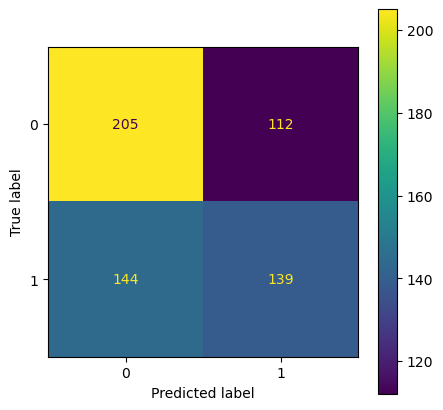

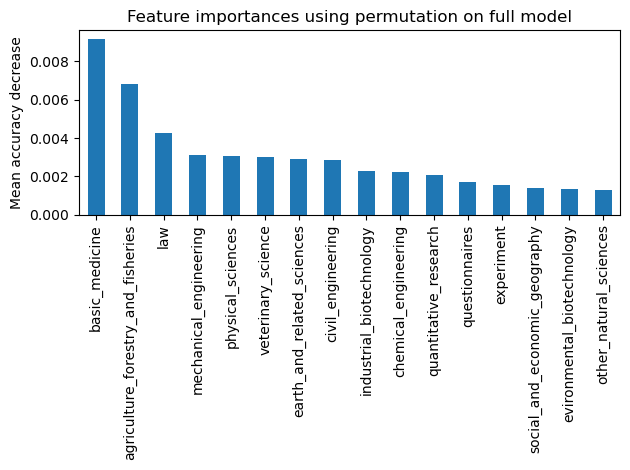

In [12]:
train_logreg(X_train_c19,y_train_c19, X_test_c19, y_test_c19)

Fitting 5 folds for each of 2000 candidates, totalling 10000 fits


"Best params: {'n_estimators': 200, 'min_samples_split': 90, 'min_samples_leaf': 30, 'max_features': 30, 'max_depth': 10}"

'Random Forest Classifier Accuracy score: 0.59'

'Random Forest Classifier Recall score: 0.5892476953773784'

'Random Forest Classifier F1 score: 0.5891051623535699'

'Random Forest Classifier Precision score: 0.5890808753991477'

'Random Forest Classifier MAE score: 0.41'

'Random Forest Classifier RMSE score: 0.6403124237432849'

'Random Forest Classifier MSE score: 0.41'

basic_medicine                        0.029944
biological_sciences                   0.010500
novelty                               0.010333
descriptive_research                  0.002833
applied_research                      0.002778
secondary_research                    0.002056
quantitative_research                 0.001722
rigor                                 0.001556
correlational_research                0.000722
chemical_sciences                     0.000667
agriculture_forestry_and_fisheries    0.000444
political_science                     0.000111
focus_groups                          0.000000
nano-technology                       0.000000
law                                   0.000000
social_and_economic_geography         0.000000
dtype: float64

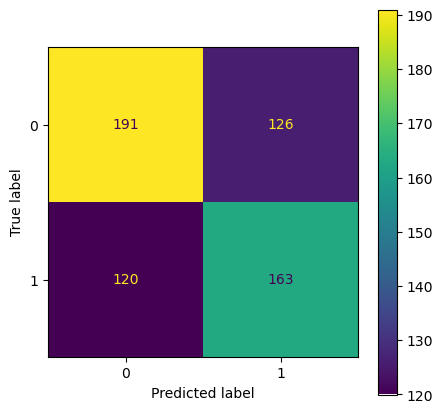

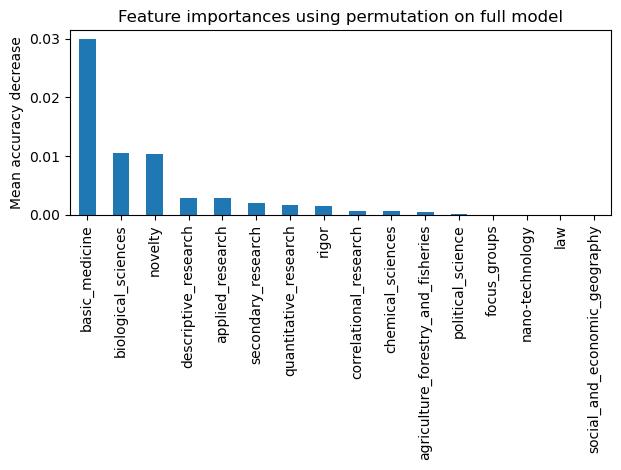

In [13]:
train_rfc(X_train=X_train_c19, y_train=y_train_c19, X_test=X_test_c19, y_test=y_test_c19)

Fitting 5 folds for each of 2000 candidates, totalling 10000 fits


"Best params: {'n_estimators': 100, 'min_samples_split': 30, 'min_samples_leaf': 90, 'max_features': 'log2', 'max_depth': 45}"

'Gradient Boosting Classifier Accuracy score: 0.5916666666666667'

'Gradient Boosting Classifier Recall score: 0.5917724693738784'

'Gradient Boosting Classifier F1 score: 0.5912567880569126'

'Gradient Boosting Classifier Precision score: 0.591481843637495'

'Gradient Boosting Classifier MAE score: 0.4083333333333333'

'Gradient Boosting Classifier RMSE score: 0.6390096504226938'

'Gradient Boosting Classifier MSE score: 0.4083333333333333'

basic_medicine            0.018500
biological_sciences       0.010889
veterinary_science        0.010278
replicability             0.010167
novelty                   0.009778
computer_sciences         0.007222
survey_methodology        0.006444
electrical_engineering    0.004556
rigor                     0.004278
mixed_methods             0.004111
applied_research          0.004056
correlational_research    0.003944
accessibility             0.003833
economics_and_business    0.003500
descriptive_research      0.003222
chemical_sciences         0.003111
dtype: float64

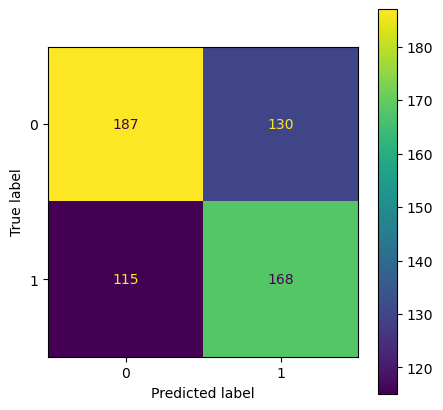

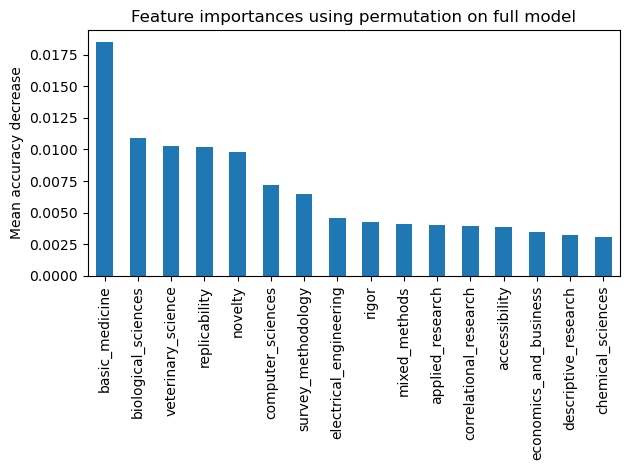

In [14]:
train_gbc(X_train=X_train_c19, y_train=y_train_c19, X_test=X_test_c19, y_test=y_test_c19)

Fitting 5 folds for each of 2000 candidates, totalling 10000 fits


"Best params: {'n_estimators': 100, 'min_samples_split': 90, 'min_samples_leaf': 90, 'max_features': 'log2', 'max_depth': 20}"

'Gradient Boosting Classifier Accuracy score: 0.5966666666666667'

'Gradient Boosting Classifier Recall score: 0.5963148331865658'

'Gradient Boosting Classifier F1 score: 0.5960202991452992'

'Gradient Boosting Classifier Precision score: 0.5960578537203589'

'Gradient Boosting Classifier MAE score: 0.4033333333333333'

'Gradient Boosting Classifier RMSE score: 0.6350852961085883'

'Gradient Boosting Classifier MSE score: 0.4033333333333333'

novelty                     0.013778
basic_medicine              0.012056
biological_sciences         0.011667
electrical_engineering      0.010111
quantitative_research       0.008833
economics_and_business      0.008278
veterinary_science          0.008111
replicability               0.007667
rigor                       0.006556
computer_sciences           0.005889
qualitative_research        0.005833
media_and_communications    0.005111
chemical_sciences           0.004000
physical_sciences           0.003167
political_science           0.003111
sociology                   0.002611
dtype: float64

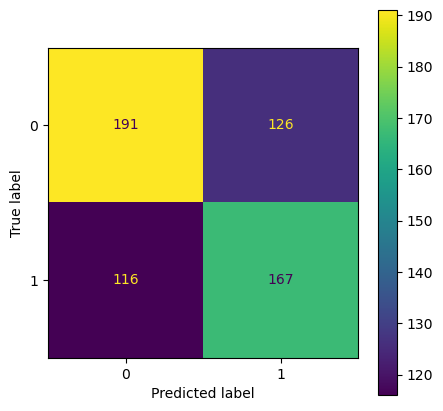

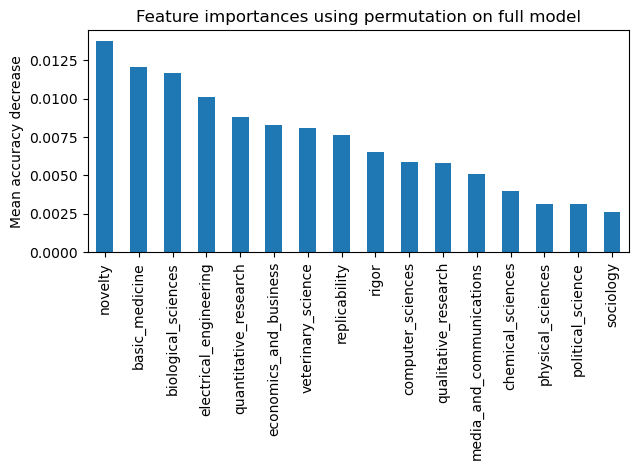

In [15]:
train_gbc(X_train=X_train_c19, y_train=y_train_c19, X_test=X_test_c19, y_test=y_test_c19)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


"Best params: {'n_estimators': 1000, 'learning_rate': 0.4}"

'Ada Boosting Classifier Accuracy score: 0.5716666666666667'

'Ada Boosting Classifier Recall score: 0.5703815585602657'

'Ada Boosting Classifier F1 score: 0.570367026923109'

'Ada Boosting Classifier Precision score: 0.5703556783740418'

'Ada Boosting Classifier MAE score: 0.42833333333333334'

'Ada Boosting Classifier RMSE score: 0.6544717972023953'

'Ada Boosting Classifier MSE score: 0.42833333333333334'

basic_medicine                        0.023500
agriculture_forestry_and_fisheries    0.016556
biological_sciences                   0.007889
descriptive_research                  0.007222
rigor                                 0.006222
animal_and_dairy_science              0.004389
accessibility                         0.002667
earth_and_related_sciences            0.002000
questionnaires                        0.001889
veterinary_science                    0.001222
sociology                             0.000222
focus_groups                          0.000167
history_and_archaeology               0.000000
secondary_research                    0.000000
agricultural_biotechnology            0.000000
psychology                            0.000000
dtype: float64

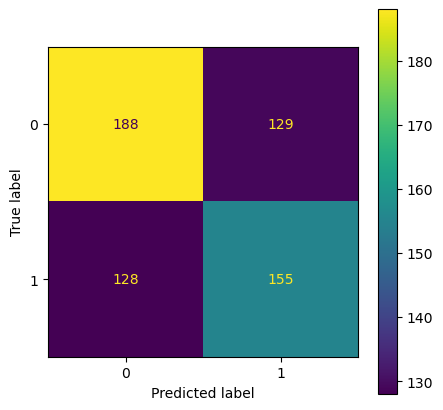

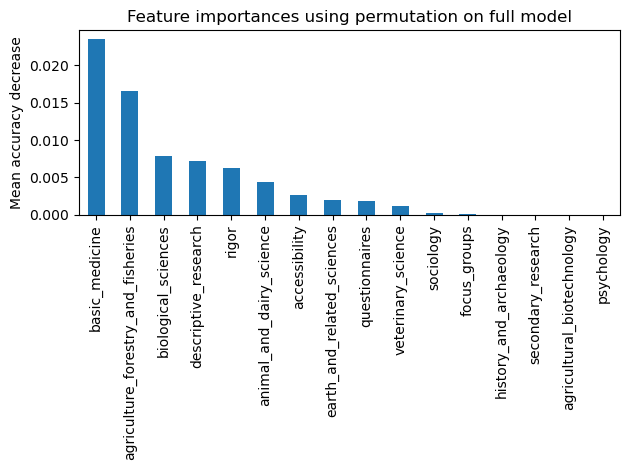

In [16]:
train_abc(X_train=X_train_c19, y_train=y_train_c19, X_test=X_test_c19, y_test=y_test_c19)

'SVM Accuracy score: 0.565'

'SVM Recall score: 0.5591454782579617'

'SVM F1 score: 0.5569249573476611'

'SVM Precision score: 0.5617666232073011'

'SVM MAE score: 0.435'

'SVM RMSE score: 0.6595452979136459'

'SVM MSE score: 0.435'

biological_sciences           0.028833
basic_medicine                0.017667
veterinary_science            0.005278
chemical_sciences             0.005111
psychology                    0.004111
mixed_methods                 0.003778
mathematics                   0.003389
replicability                 0.002722
accessibility                 0.002667
evironmental_biotechnology    0.002222
political_science             0.002056
media_and_communications      0.002000
descriptive_research          0.001944
observation                   0.001944
animal_and_dairy_science      0.001778
experiment                    0.001667
dtype: float64

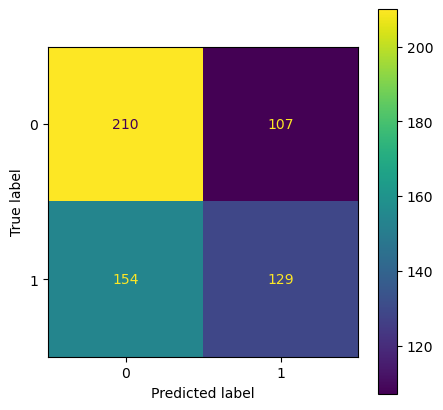

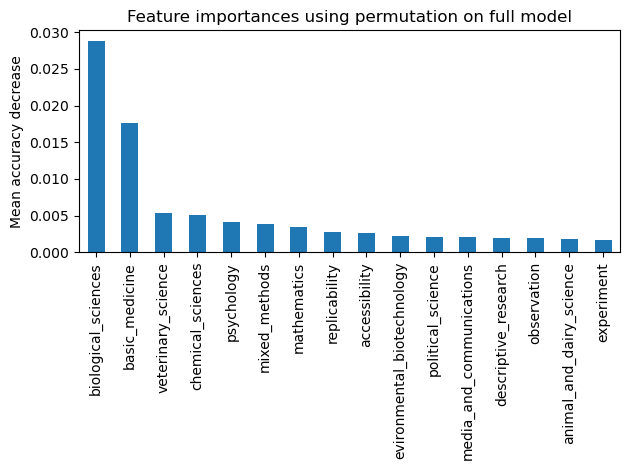

In [17]:
train_svm(X_train=X_train_c19, y_train=y_train_c19, X_test=X_test_c19, y_test=y_test_c19)

# M17+ dataset models
- unimodal, only generated features used
- Random Forest, Gradient Boost, Ada Boost, SVM

Fitting 5 folds for each of 2000 candidates, totalling 10000 fits


"Best params: {'n_estimators': 200, 'min_samples_split': 60, 'min_samples_leaf': 30, 'max_features': 'sqrt', 'max_depth': 45}"

'Random Forest Classifier Accuracy score: 0.355'

'Random Forest Classifier Recall score: 0.3526202217062524'

'Random Forest Classifier F1 score: 0.2653791818309993'

'Random Forest Classifier Precision score: 0.35642674467811075'

'Random Forest Classifier MAE score: 1.275'

'Random Forest Classifier RMSE score: 1.7804493814764855'

'Random Forest Classifier MSE score: 3.17'

replicability             0.029417
rigor                     0.021167
novelty                   0.012333
biological_sciences       0.007333
mechanical_engineering    0.005750
chemical_engineering      0.005667
basic_medicine            0.005333
mixed_methods             0.002833
grammar                   0.002833
accessibility             0.002750
materials_engineering     0.002667
applied_research          0.001583
sociology                 0.001333
other_medical_sciences    0.001333
electrical_engineering    0.001083
exploratory_research      0.001000
dtype: float64

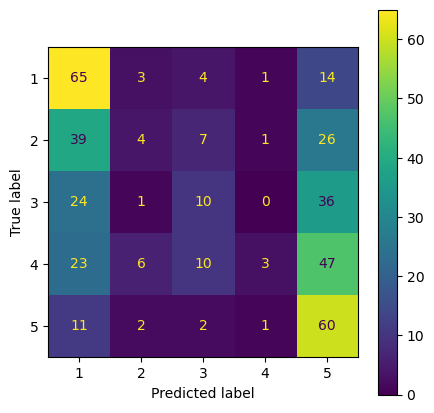

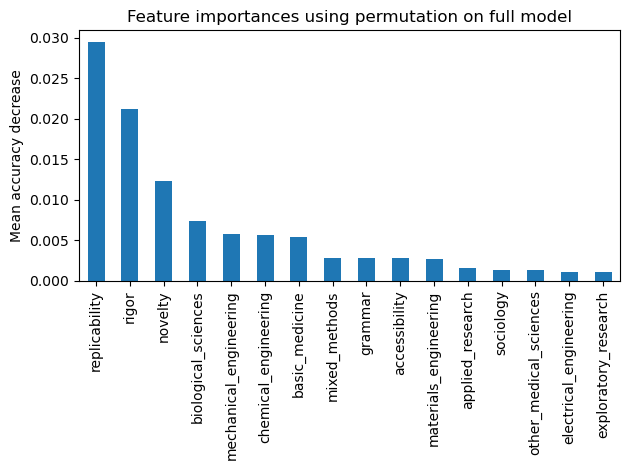

In [18]:
train_rfc(X_train=X_train_m17, y_train=y_train_m17, X_test=X_test_m17, y_test=y_test_m17)

Fitting 5 folds for each of 2000 candidates, totalling 10000 fits


"Best params: {'n_estimators': 100, 'min_samples_split': 50, 'min_samples_leaf': 60, 'max_features': 'log2', 'max_depth': 40}"

'Gradient Boosting Classifier Accuracy score: 0.355'

'Gradient Boosting Classifier Recall score: 0.35080688178165353'

'Gradient Boosting Classifier F1 score: 0.3255916997909017'

'Gradient Boosting Classifier Precision score: 0.3333365969126942'

'Gradient Boosting Classifier MAE score: 1.1125'

'Gradient Boosting Classifier RMSE score: 1.5644487847162014'

'Gradient Boosting Classifier MSE score: 2.4475'

rigor                       0.039917
biological_sciences         0.032833
grammar                     0.029000
replicability               0.028667
other_social_sciences       0.014333
physical_sciences           0.014167
mixed_methods               0.010917
economics_and_business      0.010833
other_medical_sciences      0.010333
medical_biotechnology       0.010250
sociology                   0.009333
media_and_communications    0.008500
qualitative_research        0.008333
applied_research            0.008167
education                   0.008083
civil_engineering           0.008000
dtype: float64

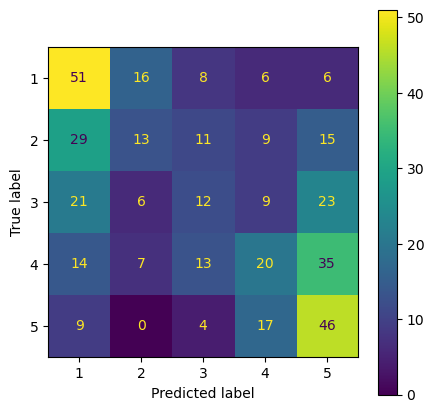

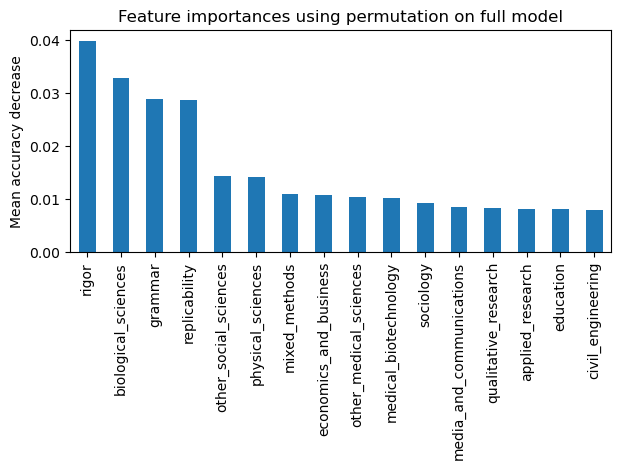

In [10]:
train_gbc(X_train=X_train_m17, y_train=y_train_m17, X_test=X_test_m17, y_test=y_test_m17)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


"Best params: {'n_estimators': 400, 'learning_rate': 1}"

'Ada Boosting Classifier Accuracy score: 0.3725'

'Ada Boosting Classifier Recall score: 0.3669194467510065'

'Ada Boosting Classifier F1 score: 0.34522470760428714'

'Ada Boosting Classifier Precision score: 0.3460503348141047'

'Ada Boosting Classifier MAE score: 1.1'

'Ada Boosting Classifier RMSE score: 1.5700318468107581'

'Ada Boosting Classifier MSE score: 2.465'

rigor                                 0.081333
grammar                               0.028083
biological_sciences                   0.024250
novelty                               0.019417
replicability                         0.019167
physical_sciences                     0.014083
veterinary_science                    0.013583
sociology                             0.013417
psychology                            0.012917
qualitative_research                  0.011250
mathematics                           0.010000
questionnaires                        0.006917
agriculture_forestry_and_fisheries    0.006917
civil_engineering                     0.006667
materials_engineering                 0.004917
correlational_research                0.004500
dtype: float64

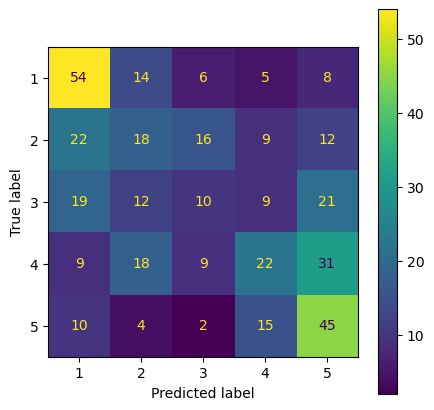

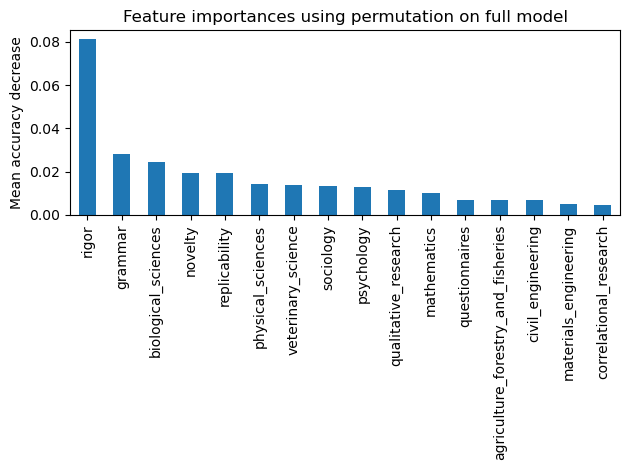

In [11]:
train_abc(X_train=X_train_m17, y_train=y_train_m17, X_test=X_test_m17, y_test=y_test_m17)

,novelty,rigor,grammar,replicability,accessibility,mathematics,computer_and_information_sciences,physical_sciences,chemical_sciences,earth_and_related_environmental_sciences,...,focus_groups,interviews,mixed_methods,observation,qualitative_research,quantitative_research,questionnaires,secondary_research,survey_methodology,Intercept
0,0.126210,0.249042,-0.165094,0.120201,0.008417,0.083425,0.057825,0.113582,0.082028,-0.009616,...,-0.034277,-0.051540,0.044679,-0.016186,-0.036709,0.011611,-0.025779,-0.013486,0.015507,-0.126799
1,0.053225,0.105897,-0.052864,0.066332,-0.006086,0.036742,-0.007922,0.017211,0.004519,0.060439,...,-0.009462,0.026969,-0.020817,-0.046731,-0.040859,-0.034455,-0.059960,-0.008286,0.013872,0.100084
2,-0.093941,-0.005926,0.001202,0.041705,0.034332,0.007469,0.021474,-0.016008,0.011672,0.023520,...,-0.011792,0.018081,0.033854,-0.055710,0.048452,-0.030280,0.025496,0.009737,-0.000119,0.135289
3,-0.093926,-0.145434,0.086540,-0.046457,0.035742,-0.037246,-0.035931,-0.044326,-0.060109,-0.033442,...,-0.000645,-0.014814,-0.008940,0.079276,0.063484,-0.003893,-0.017939,-0.014994,-0.009598,0.007264
4,0.008432,-0.203580,0.130217,-0.181782,-0.072405,-0.090390,-0.035445,-0.070458,-0.038110,-0.040900,...,0.056177,0.021304,-0.048776,0.039350,-0.034368,0.057017,0.078182,0.027029,-0.019663,-0.115838


'Logreg Accuracy score: 0.37'

'Logreg Recall score: 0.36998749419112464'

'Logreg F1 score: 0.3249656191051208'

'Logreg Precision score: 0.3793722943722944'

'Logreg MAE score: 1.18'

'Logreg RMSE score: 1.6792855623746665'

'Logreg MSE score: 2.82'

rigor                                 0.054417
biological_sciences                   0.035667
novelty                               0.028667
replicability                         0.023917
grammar                               0.023833
physical_sciences                     0.022750
sociology                             0.019833
media_and_communications              0.019833
mathematics                           0.018667
mechanical_engineering                0.014667
applied_research                      0.014167
education                             0.012667
veterinary_science                    0.012167
other_medical_sciences                0.011917
economics_and_business                0.011333
other_engineering_and_technologies    0.011167
dtype: float64

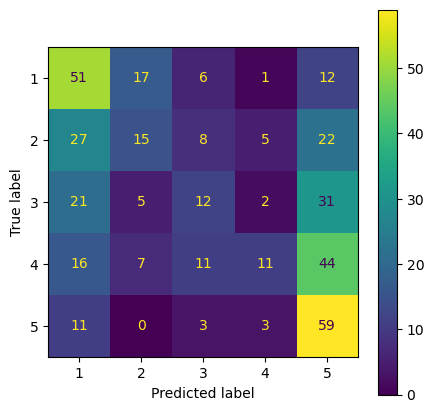

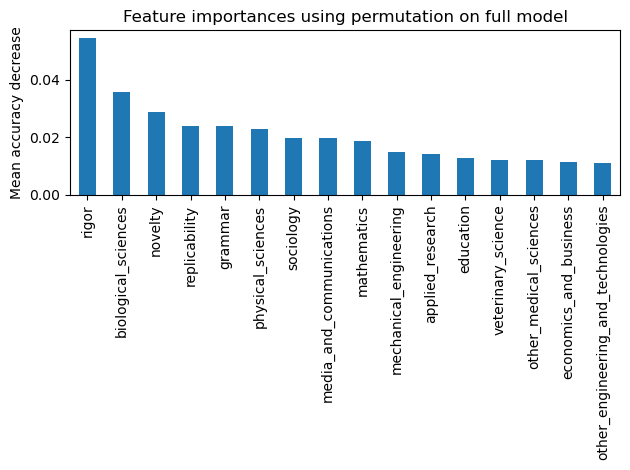

In [12]:
train_logreg(X_train=X_train_m17, y_train=y_train_m17, X_test=X_test_m17, y_test=y_test_m17)

'SVM Accuracy score: 0.3375'

'SVM Recall score: 0.3346748511637251'

'SVM F1 score: 0.30718038836449313'

'SVM Precision score: 0.3152432721999748'

'SVM MAE score: 1.15'

'SVM RMSE score: 1.6046806535881213'

'SVM MSE score: 2.575'

rigor                       0.072000
biological_sciences         0.031667
replicability               0.027417
mechanical_engineering      0.010583
economics_and_business      0.009667
qualitative_research        0.009333
grammar                     0.009167
other_natural_sciences      0.009000
media_and_communications    0.008500
applied_research            0.008417
medical_biotechnology       0.007583
sociology                   0.006667
chemical_sciences           0.006500
physical_sciences           0.006333
other_social_sciences       0.003917
clinical_medicine           0.003833
dtype: float64

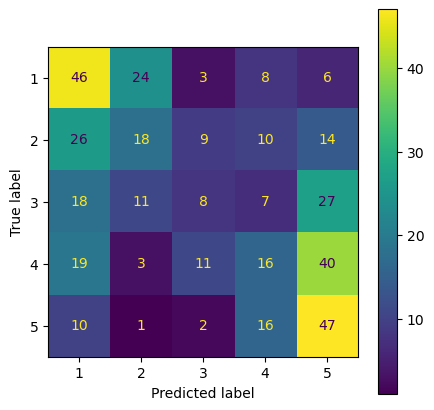

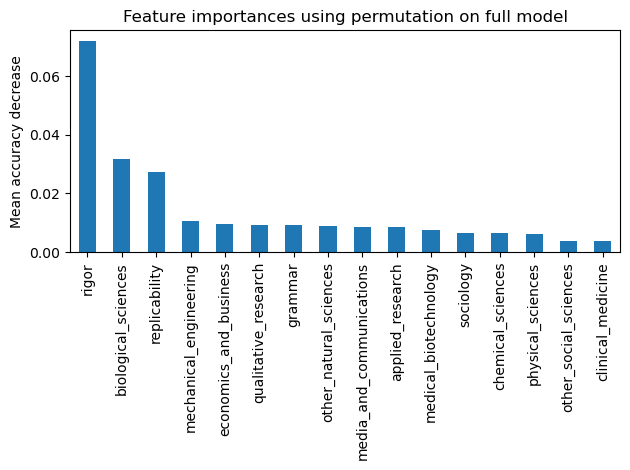

In [13]:
train_svm(X_train=X_train_m17, y_train=y_train_m17, X_test=X_test_m17, y_test=y_test_m17)